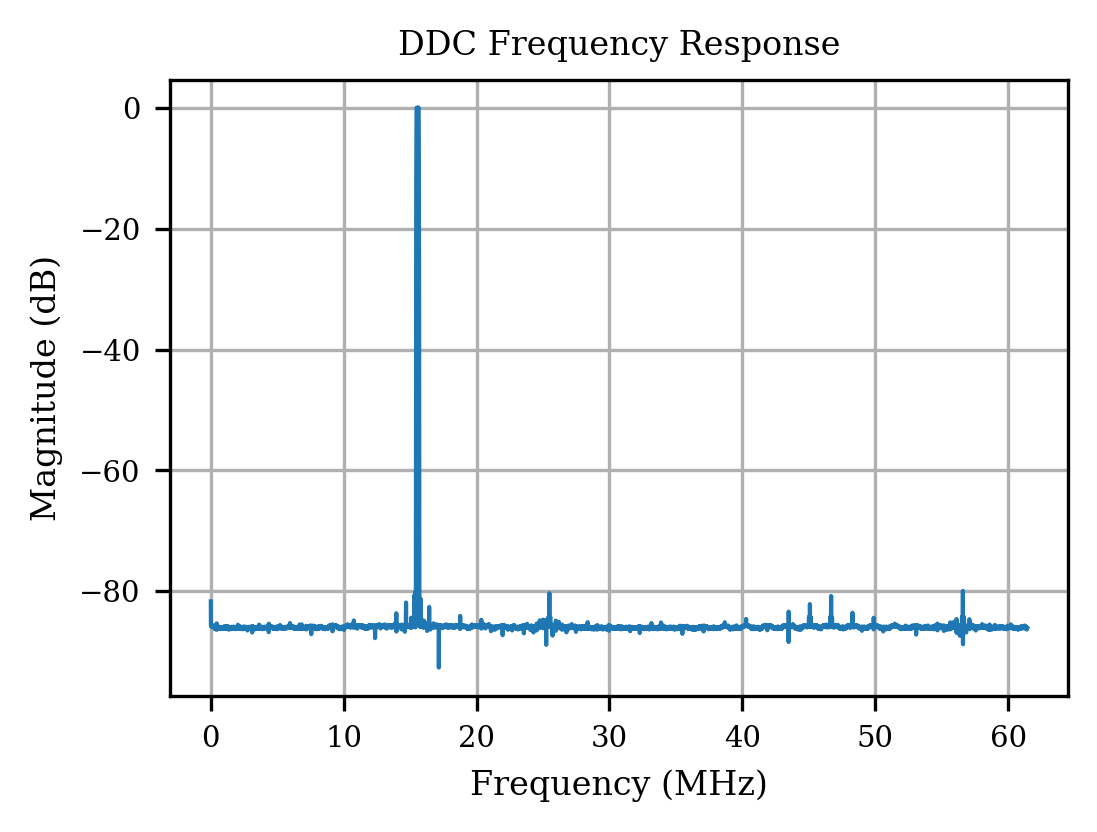

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# load ddc attenuation data from csv file using numpy
freqs, attenuations = np.loadtxt("ddc_attenuation_full.csv", delimiter=",", skiprows=1, unpack=True)

# convert frequencies to MHz
freqs = freqs / 1e6 

# plot settings for Elsevier 5p single-column figure (90 mm width)
fig_width_in = 90 / 25.4 # mm -> inches
fig_height_in = fig_width_in * 0.75

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 8,
    "axes.labelsize": 8,
    "axes.titlesize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "lines.linewidth": 1.0,
})

plt.figure(figsize=(fig_width_in, fig_height_in), dpi=300, constrained_layout=True)
plt.plot(freqs, attenuations)
plt.xlabel("Frequency (MHz)")
plt.ylabel("Magnitude (dB)")
plt.title("DDC Frequency Response")
plt.grid(True)

# Save the figure as a high-resolution PNG file, nerrow down the bounding box to remove extra whitespace
plt.savefig("ddc_frequency_response_full.png", dpi=300, bbox_inches='tight')

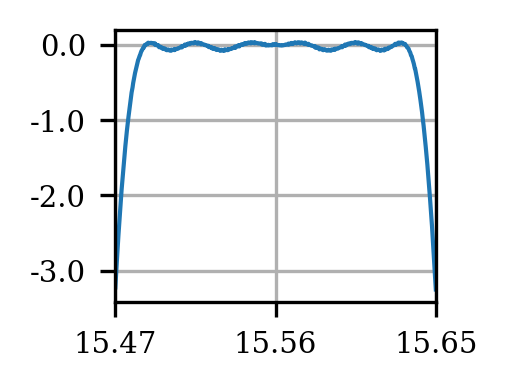

In [23]:
# load fine ddc attenuation data from csv file using numpy
freqs_fine, attenuations_fine = np.loadtxt("ddc_attenuation_fine_180k.csv", delimiter=",", skiprows=1, unpack=True)

# convert frequencies to MHz
freqs_fine = freqs_fine / 1e6

# plot settings for Elsevier 5p single-column figure (40 mm width)
fig_width_in = 40 / 25.4 # mm -> inches
fig_height_in = fig_width_in * 0.75
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 8,
    "axes.labelsize": 8,
    "axes.titlesize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "lines.linewidth": 1.0,
})
plt.figure(figsize=(fig_width_in, fig_height_in), dpi=300, constrained_layout=True)
plt.plot(freqs_fine, attenuations_fine)
plt.xlim(15.56 - 0.09, 15.56 + 0.09)
plt.xticks([15.47, 15.56, 15.65], [f"{x:.2f}" for x in [15.47, 15.56, 15.65]])
plt.yticks([-3, -2, -1,  0], [f"{y:.1f}" for y in [-3, -2, -1, 0]])
plt.grid(True)

# save the figure as a high-resolution PNG file, nerrow down the bounding box to remove extra whitespace
plt.savefig("ddc_frequency_response_fine_180k.png", dpi=300, bbox_inches='tight', transparent=True)

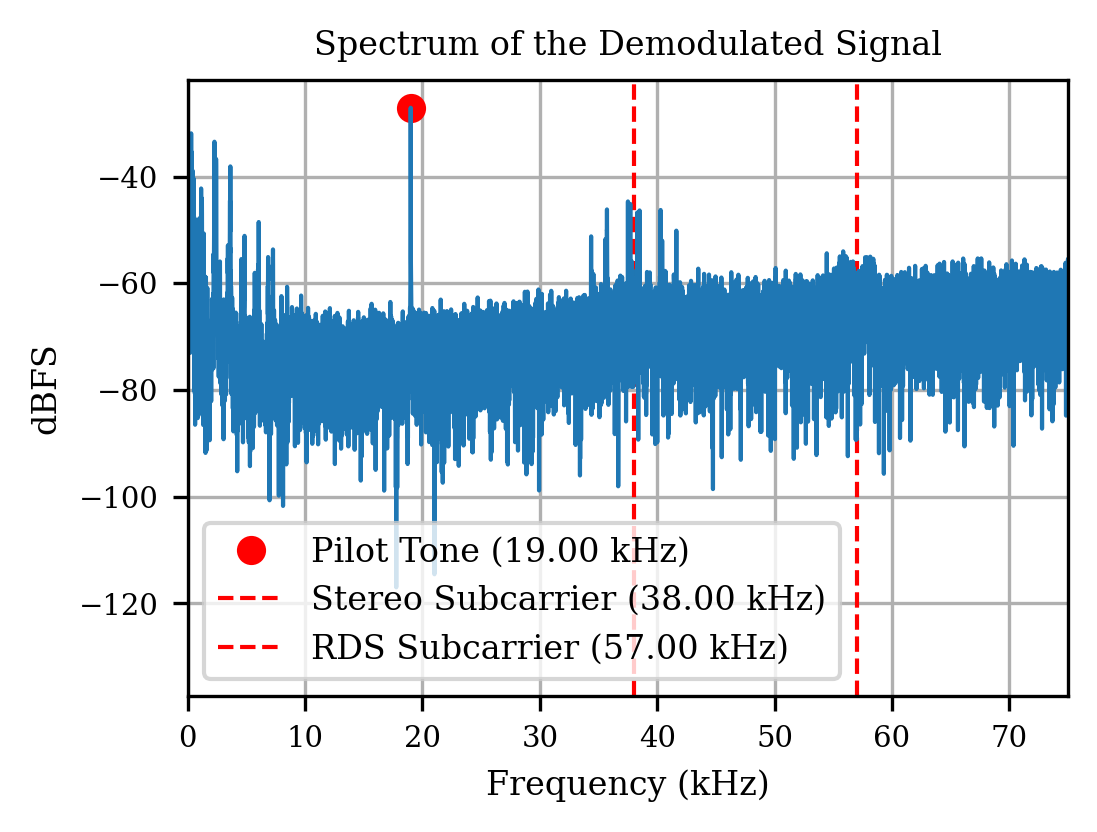

In [28]:
fs = 960e3
ts = 1/fs

data = np.loadtxt("demodulated_96_2.csv", delimiter=",", skiprows=2)

data = data[:, -1]



# calculate the spectrum of the signal, and convert to dBm (50ohm)
n = len(data)
#window = hann(n)
#data_ = data * window
fft_data = np.fft.fftshift(np.fft.fft(data)) / n
freqs = np.fft.fftshift(np.fft.fftfreq(n, ts))

# get the positive frequencies and corresponding spectrum
freqs = freqs[n//2:]
fft_data = fft_data[n//2:]

# Convert to dBFS
full_scale = 2**28
dbFS_spectrum = 20 * np.log10(np.abs(fft_data) / full_scale)


# plot half spectrum
fig_width_in = 90 / 25.4
fig_height_in = fig_width_in * 0.75

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 8,
    "axes.labelsize": 8,
    "axes.titlesize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "lines.linewidth": 1.0,
})
plt.figure(figsize=(fig_width_in, fig_height_in), dpi=300, constrained_layout=True)
#plt.figure(figsize=(12, 6))
# mark the maximum point
max_idx = np.argmax(dbFS_spectrum[1:]) + 1  # skip the DC component
plt.plot(freqs[max_idx] / 1e3, dbFS_spectrum[max_idx], 'ro', label='Pilot Tone ({:.2f} kHz)'.format(freqs[max_idx]/1e3))
plt.axvline(38, color='r', linestyle='--', label='Stereo Subcarrier (38.00 kHz)')
plt.axvline(57, color='r', linestyle='--', label='RDS Subcarrier (57.00 kHz)')
plt.plot(freqs / 1e3, dbFS_spectrum)
plt.xlim(0, 75)
#plt.xlim(0, 100e3)
plt.xlabel("Frequency (kHz)")
plt.ylabel("dBFS")
plt.grid(True)
plt.legend()

plt.title("Spectrum of the Demodulated Signal")

# save the figure
plt.savefig("spectrum_demodulated_signal.png")